# Router

## Review
We built a graph (`simple_graph.ipynb`) that uses `messages` as state and a chat model with bound tools. 

We saw that the graph can:
- Return a tool call
- Return a natural language response

## Goals
We can think of this as a router, where the chat model routes between a direct response or a tool call based upon the user input.

This is a simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly.

For this, we can use two ideas:
1. Add a node that will call our tool.
2. Add a conditional edge that will look at the chat model output, and route to our tool calling node or simply end if no tool call is performed.


In [1]:
# Import libraries
import os, getpass
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    """
    return a * b

llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)
llm_with_tools = llm.bind_tools([multiply])

We use built-in `ToolNode` and simply pass a list of our tools to initialize it. We use built-in `tool_condition` as our conditional edge.

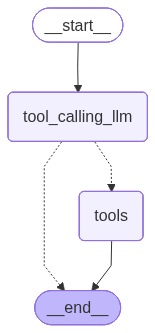

In [2]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_00_KYxBzKk3u74AcQbrpCBJ4548)
 Call ID: call_00_KYxBzKk3u74AcQbrpCBJ4548
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
